In [1]:
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [2]:
print("Available Devices:")
print(tf.config.list_physical_devices())

Available Devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_path = "/content/drive/MyDrive/Colab Notebooks/dataset/train"
test_path = "/content/drive/MyDrive/Colab Notebooks/dataset/test"
IMG_SIZE = 224
BATCH_SIZE = 32

print("Train Classes:", os.listdir(train_path))
print("Test Classes:", os.listdir(test_path))

Train Classes: ['healthy', 'down_syndrome']
Test Classes: ['down_syndrome', 'healthy']


In [9]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
          validation_split=0.2,
              rotation_range=20,
                  zoom_range=0.2,
                      horizontal_flip=True,
                          width_shift_range=0.1,
                              height_shift_range=0.1
                              )

test_datagen = ImageDataGenerator(
          rescale=1./255
         )


In [10]:
train_data = train_datagen.flow_from_directory(
      train_path,
          target_size=(IMG_SIZE, IMG_SIZE),
              batch_size=BATCH_SIZE,
                  class_mode='binary',
                      subset='training'
                      )


Found 984 images belonging to 2 classes.


In [11]:
val_data = train_datagen.flow_from_directory(
      train_path,
          target_size=(IMG_SIZE, IMG_SIZE),
              batch_size=BATCH_SIZE,
                  class_mode='binary',
                      subset='validation'
                      )


Found 246 images belonging to 2 classes.


In [12]:
test_generator = test_datagen.flow_from_directory(
      test_path,
          target_size=(IMG_SIZE, IMG_SIZE),
              batch_size=BATCH_SIZE,
                  class_mode='binary',
                      shuffle=False
                      )


Found 1769 images belonging to 2 classes.


In [13]:
base_model = VGG16(
      weights='imagenet',
          include_top=False,
              input_shape=(IMG_SIZE, IMG_SIZE, 3)
              )


for layer in base_model.layers:
      layer.trainable = False


for layer in base_model.layers[-8:]:
       layer.trainable = True


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
x = base_model.output
x = Flatten()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(
    inputs=base_model.input,
        outputs=output
        )

In [21]:
model.compile(
      optimizer=Adam(learning_rate=2e-5),
          loss='binary_crossentropy',
              metrics=['accuracy']
              )

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 18,026,561 (68.77 MB)

 Trainable params: 16,240,897 (61.95 MB)

 Non-trainable params: 1,785,664 (6.81 MB)

In [22]:
early_stop = EarlyStopping(
      monitor='val_loss',
          patience=3,
              restore_best_weights=True
              )


In [23]:
history = model.fit(
      train_data,
          validation_data=val_data,
              epochs=15,
                  callbacks=[early_stop]
                  )


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 404s 12s/step - accuracy: 0.6087 - loss: 0.7554 - val_accuracy: 0.6504 - val_loss: 0.6373
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 771ms/step - accuracy: 0.7276 - loss: 0.5838 - val_accuracy: 0.6870 - val_loss: 0.5879
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 709ms/step - accuracy: 0.7419 - loss: 0.5415 - val_accuracy: 0.7033 - val_loss: 0.5661
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 757ms/step - accuracy: 0.7876 - loss: 0.4757 - val_accuracy: 0.6870 - val_loss: 0.5863
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 729ms/step - accuracy: 0.8130 - loss: 0.4277 - val_accuracy: 0.6992 - val_loss: 0.5599
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 730ms/step - accuracy: 0.8191 - loss: 0.3836 - val_accuracy: 0.6504 - val_loss: 0.6185
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 753ms/step - accuracy: 0.8598 - loss: 0.3256 - val_accuracy: 0.7642 - val_loss: 0.5177
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 711ms/step - accuracy: 0.8567 - loss: 0.3121 - val_accur

In [24]:
test_loss, test_acc = model.evaluate(test_generator)

print("Final Test Accuracy:", test_acc * 100, "%")

17/56 ━━━━━━━━━━━━━━━━━━━━ 5:58 9s/step - accuracy: 0.9351 - loss: 0.1584

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


56/56 ━━━━━━━━━━━━━━━━━━━━ 522s 9s/step - accuracy: 0.8519 - loss: 0.3727
Final Test Accuracy: 85.18937230110168 %


In [25]:
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

y_true = test_generator.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       885
           1       0.93      0.76      0.84       884

    accuracy                           0.85      1769
   macro avg       0.86      0.85      0.85      1769
weighted avg       0.86      0.85      0.85      1769


Confusion Matrix:

[[833  52]
 [210 674]]


In [26]:
model.save(
      "/content/drive/MyDrive/Colab Notebooks/vgg16_down_syndrome_model.keras"
      )

print("\nVGG16 Model Saved Successfully")



VGG16 Model Saved Successfully


In [14]:
# Dataset Loading
print(train_data.class_indices)

print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)

{'down_syndrome': 0, 'healthy': 1}
Training samples: 984
Validation samples: 246


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

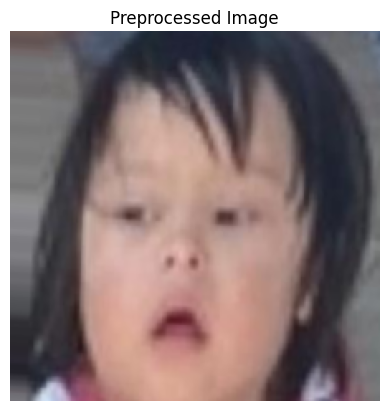

In [16]:
# Image Preprocessing & Resizing
import matplotlib.pyplot as plt

img, label = next(train_data)

plt.imshow(img[0])
plt.title("Preprocessed Image")
plt.axis('off')

Text(0.5, 0.98, 'Augmented Images')

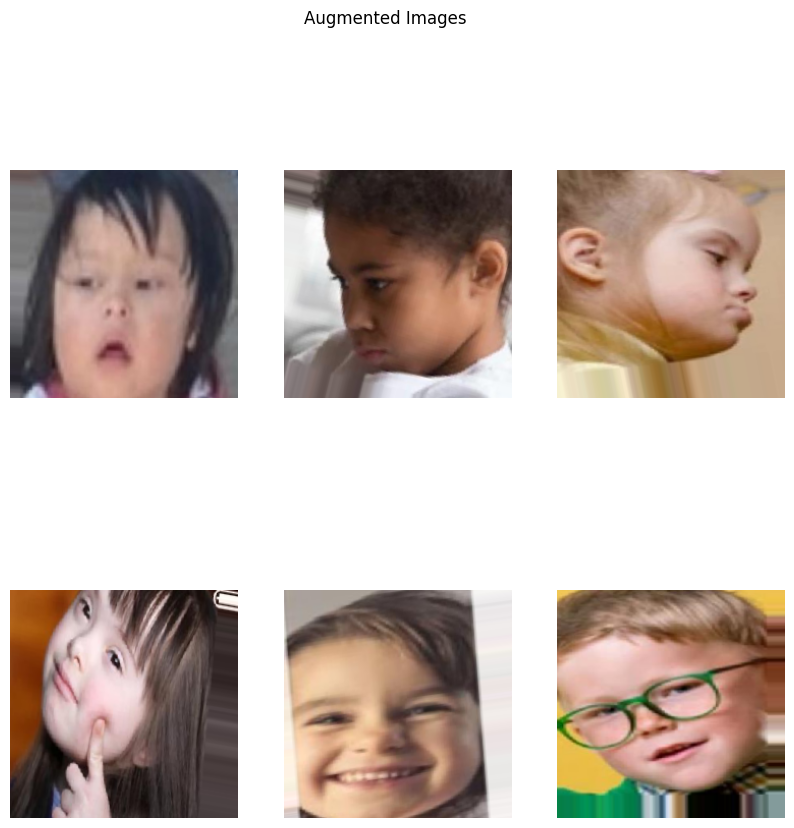

In [18]:
# Data Augmentation
plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(img[i])
    plt.axis('off')

plt.suptitle("Augmented Images")

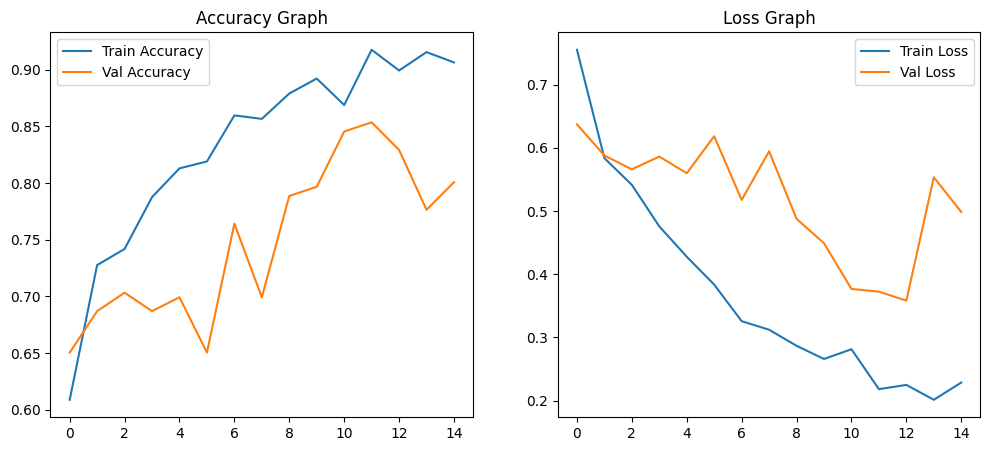

In [27]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")

plt.show()

Text(45.722222222222214, 0.5, 'Actual')

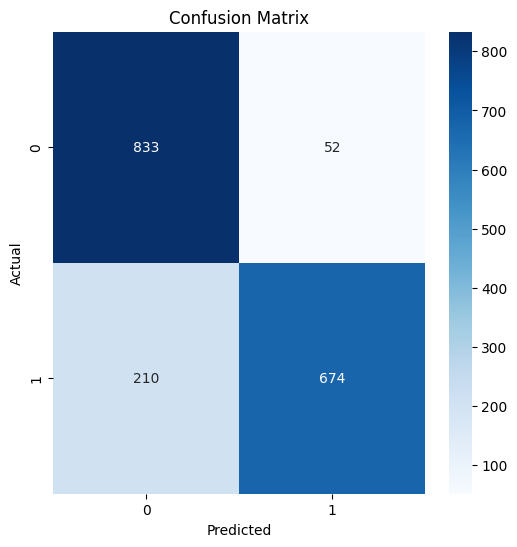

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")